# Findings 

- when an action leads to collide to the wall, it does nothing (stays in the same position before the action). 

- dot can be inside the wall 

- last state is discarded to match the action shape. 

In [421]:
import random
import sys
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

REPO_ROOT = Path.cwd().parents[1]          # examples/my_ac_video_jepa -> repo root
sys.path.insert(0, str(REPO_ROOT))

from eb_jepa.datasets.utils import init_data
from eb_jepa.datasets.two_rooms.utils import generate_wall_layouts

# torch.manual_seed(0); np.random.seed(0); random.seed(0)

### `load_env_data_config`

In [ ]:
import yaml 


DATASETS_DIR = Path("/Users/hawardizayee/Desktop/AMI/eb_jepa/eb_jepa/datasets")
config_path = DATASETS_DIR / "two_rooms" / "data_config.yaml"

print(config_path)

with open(config_path) as f:
    base_config = yaml.safe_load(f)

base_config

/Users/hawardizayee/Desktop/AMI/eb_jepa/eb_jepa/datasets/two_rooms/data_config.yaml


In [ ]:
overrides = {"batch_size": 128}
base_config.update(overrides)

base_config

### `update_config_from_yaml`

In [427]:
from dataclasses import fields
from eb_jepa.datasets.two_rooms.wall_dataset import WallDatasetConfig

In [428]:
config_class = WallDatasetConfig
fields(config_class)

(Field(name='size',type=<class 'int'>,default=10000,default_factory=<dataclasses._MISSING_TYPE object at 0x108fa42c0>,init=True,repr=True,hash=None,compare=True,metadata=mappingproxy({}),kw_only=False,_field_type=_FIELD),
 Field(name='val_size',type=<class 'int'>,default=10000,default_factory=<dataclasses._MISSING_TYPE object at 0x108fa42c0>,init=True,repr=True,hash=None,compare=True,metadata=mappingproxy({}),kw_only=False,_field_type=_FIELD),
 Field(name='batch_size',type=<class 'int'>,default=128,default_factory=<dataclasses._MISSING_TYPE object at 0x108fa42c0>,init=True,repr=True,hash=None,compare=True,metadata=mappingproxy({}),kw_only=False,_field_type=_FIELD),
 Field(name='dot_std',type=<class 'float'>,default=1.3,default_factory=<dataclasses._MISSING_TYPE object at 0x108fa42c0>,init=True,repr=True,hash=None,compare=True,metadata=mappingproxy({}),kw_only=False,_field_type=_FIELD),
 Field(name='action_noise',type=<class 'float'>,default=0.2,default_factory=<dataclasses._MISSING_TYP

In [429]:
config_field_names = {f.name for f in fields(config_class)}

relevant_yaml_data = {
    key: value for key, value in base_config.items() if key in config_field_names
}

In [430]:
config = config_class(**relevant_yaml_data)  # notice the batch_size has overridden 
config

WallDatasetConfig(size=100000, val_size=10000, batch_size=128, dot_std=1.3, action_noise=1, action_angle_noise=0.2, action_step_mean=1.0, action_step_std=0.4, action_lower_bd=0.2, action_upper_bd=1.8, max_step=1, n_steps=91, img_size=65, train=True, device='cpu', repeat_actions=1, n_steps_reduce_factor=1, border_wall_loc=5, chunked_actions=False, normalize=True, fix_wall=False, fix_wall_batch_k=None, wall_padding=20, door_padding=10, wall_width=3, door_space=4, cross_wall_rate=0.35, expert_cross_wall_rate=0, wall_bump_rate=0.0, dup_traj_rate=0.0, expert_action_step_mean=0.9, expert_action_step_std=0, expert_action_lower_bd=0.9, expert_action_upper_bd=0.9, expert_traj_door_padding=2, exclude_wall_train='', exclude_door_train='', only_wall_val='', only_door_val='', fix_wall_location=32, fix_door_location=18, num_train_layouts=-1, image_based=True, sample_length=17)

# WallDataset

In [431]:
from eb_jepa.datasets.two_rooms.wall_dataset import WallDataset

dset = WallDataset(config=config)
dset

In [432]:
# WallDataset generates a fresh random sample on every __getitem__ (the index is
# ignored), so re-seed right before sampling -> rerunning this cell always
# reproduces the same trajectory.
# SAMPLE_SEED = 0
# torch.manual_seed(SAMPLE_SEED); np.random.seed(SAMPLE_SEED); random.seed(SAMPLE_SEED)

sample = dset[0] # the data is generated on the fly, 
# the index is meaningless in context of different sample, 
# it only exists for DataLoader 

states, actions, locations, wall_x, door_y = sample

print(states.shape) # [C, T, H, W]
print(actions.shape)

# # this is what builds the states in dot channel. 
print(locations.shape)  

# There are logic for how thick is the wall size, and how large is the door in terms of pixels. (safely ignored)
print(wall_x.shape)
print(door_y.shape)


torch.Size([2, 17, 65, 65])
torch.Size([2, 17])
torch.Size([2, 17])
torch.Size([1])
torch.Size([1])


### locations 

- This is the normalized (x,y) where the dot trajectory is generated. 

In [433]:
locations 


tensor([[ 0.3547,  0.3763,  0.4012,  0.4456,  0.4664,  0.5352,  0.5835,  0.6169,
          0.6169,  0.6169,  0.6169,  0.6169,  0.6169,  0.6169,  0.6169,  0.6169,
          0.6457],
        [ 0.0114, -0.0300, -0.0954, -0.1368, -0.1638, -0.2333, -0.2808, -0.3731,
         -0.3731, -0.3731, -0.3731, -0.3731, -0.3731, -0.3731, -0.3731, -0.3731,
         -0.3226]])

In [434]:
locations[:, 2] # (x,y) at timestep = 2  

tensor([ 0.4012, -0.0954])

### actions 


- actions are not normalized, they stay in raw pixel. 

- What does the (x, y) mean? It's a displacement vector (Δx, Δy): "move Δx pixels horizontally and Δy pixels vertically this timestep.

- ‖(Δx, Δy)‖ ∈ [0.2, 1.8]

In [435]:
actions 

tensor([[ 0.3490,  0.3995,  0.7154,  0.3354,  1.1070,  0.7777,  0.5391,  0.6765,
          0.6403,  0.8129,  1.0129,  0.5063,  1.4031,  0.5313,  0.7103,  0.4624,
          0.3200],
        [-0.6690, -1.0551, -0.6679, -0.4354, -1.1219, -0.7663, -1.4887, -0.9501,
         -0.4490, -0.4531, -0.7274, -0.2850, -0.0061,  0.6102,  0.9112,  0.8146,
          0.1675]])

###  wall_x and door_y

- the size of the door comes from the door space (which is 4 in the config)

In [436]:
print(wall_x)   # the vertical line in to create the wall 
print(door_y)   # the gap in y axis 

tensor([43])
tensor([21])


### States

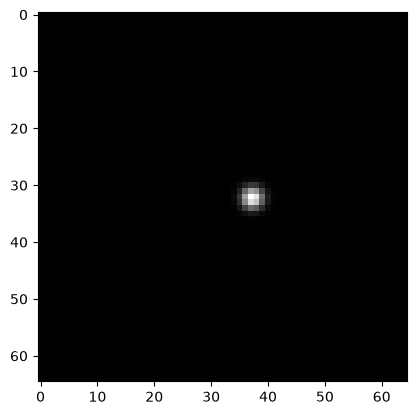

In [437]:
import matplotlib.pyplot as plt 

dot_channel = 0 
plt.imshow(states[dot_channel, 0],cmap="gray")

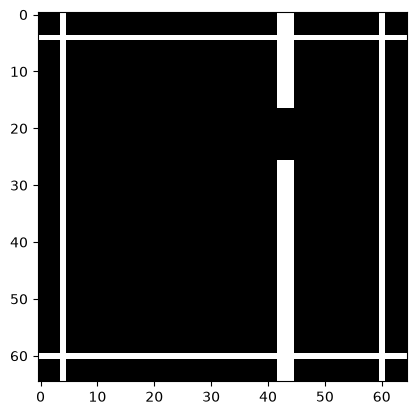

In [438]:
wall_channel = 1 
plt.imshow(states[wall_channel,0],cmap="gray")

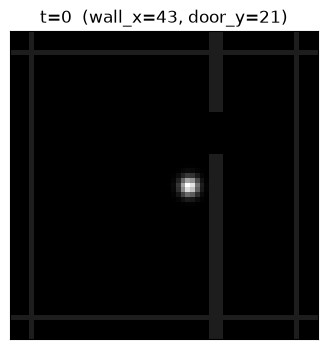

In [439]:
dot, wall = sample.states[0], sample.states[1]   # each [T, 65, 65]

t = 0  # pick any frame
frame = torch.maximum(dot[t], wall[t])

plt.figure(figsize=(4, 4))
plt.imshow(frame, cmap="gray")
plt.title(f"t={t}  (wall_x={sample.wall_x.item()}, door_y={sample.door_y.item()})")
plt.xticks([]); plt.yticks([])
plt.show()


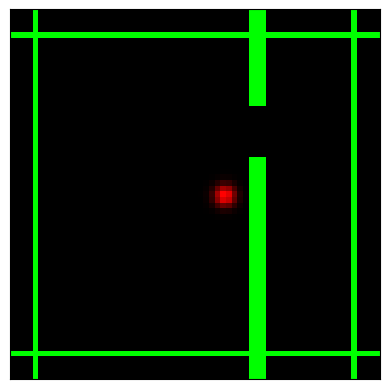

In [440]:
def to01(x):
    return (x - x.min()) / (x.max() - x.min())

rgb = torch.stack([to01(dot[t]), to01(wall[t]), torch.zeros_like(dot[t])], dim=-1)
plt.imshow(rgb)   # dot = red, wall = green
plt.xticks([]); plt.yticks([])
plt.show()


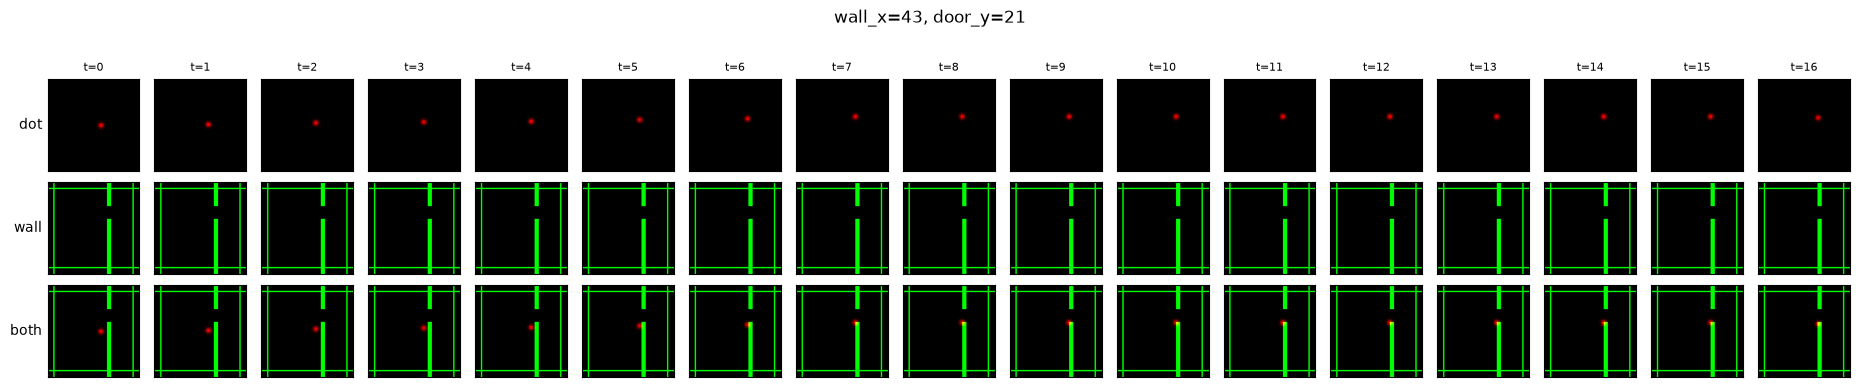

In [441]:
T = dot.shape[0]

def to01(x):
    return (x - x.min()) / (x.max() - x.min())

dot01, wall01 = to01(dot), to01(wall)            # normalize once, over the whole sequence
zeros = torch.zeros_like(dot01)

rows = [
    ("dot",  torch.stack([dot01,  zeros,  zeros], dim=-1)),   # red
    ("wall", torch.stack([zeros,  wall01, zeros], dim=-1)),   # green
    ("both", torch.stack([dot01,  wall01, zeros], dim=-1)),   # red + green
]

fig, axes = plt.subplots(3, T, figsize=(T * 1.1, 3.8))

for r, (name, frames) in enumerate(rows):        # frames: [T, 65, 65, 3]
    for t in range(T):
        ax = axes[r, t]
        ax.imshow(frames[t])
        ax.set_xticks([]); ax.set_yticks([])
        if r == 0:
            ax.set_title(f"t={t}", fontsize=8)
    axes[r, 0].set_ylabel(name, fontsize=10, rotation=0, ha="right", va="center")

fig.suptitle(f"wall_x={sample.wall_x.item()}, door_y={sample.door_y.item()}", y=1.02)
plt.tight_layout()
plt.show()
